# 機器學習期末作業：影像去噪自編碼器（CIFAR-10）

本作業聚焦於影像去噪（image denoising）。你將實作三種模型並比較重建品質：
1. 基礎 Autoencoder
2. Residual Autoencoder
3. 自行設計的模型架構

評估指標以 **LPIPS（越低越好）** 為主，並輔以重建誤差（MSE）作為訓練監控。

**姓名：洪詠竣**

**學號：M143010177**

**系級：電機碩一**

## 1. 作業目標

你需要完成以下任務：
1. 實作 `Autoencoder`。
2. 實作 `Residual Autoencoder`。
3. 自行設計一個模型架構（可自由設計 bottleneck、skip connection、normalization、activation 等）。
4. 使用相同資料設定訓練三個模型，並以 **LPIPS** 比較表現。
5. 撰寫實驗分析，說明架構差異與結果。

## 2. 作業規範

1. 資料集固定使用 CIFAR-10，不可混入測試集進行訓練。
2. 不可使用預訓練模型權重或遷移學習。
3. 三個模型都必須為你在本作業中自行撰寫的架構。
4. 三個模型需在合理且可比較的訓練條件下進行（例如相近的 epoch 與 batch size）。
5. 評估時必須回報 LPIPS（主指標，越低越好）。

## 3. 評分規準（100 分）

- Autoencoder 實作正確且可訓練：15 分
- Residual Autoencoder 實作正確且可訓練：15 分
- 自行設計模型有實作且可訓練：15 分
- 實驗設計與結果比較：15 分
- 報告完整性與程式可讀性：10 分
- 依照自行設計模型出來的 LPIPS 值與全班同學比較，LPIPS最低者得30分;最高者得5分，其餘線性給分。

## 4. 報告要求

請提交報告，至少包含以下內容：
1. 三個模型架構圖及文字說明。
2. 訓練設定（epoch、learning rate、noise factor、batch size）。
3. 三個模型在測試集的最終 LPIPS 比較表。
4. 重建結果可視化（clean/noisy/prediction 對照）。
5. 分析：
   - 分別哪個模型 LPIPS 最高/低？原因是什麼？
   - 你設計的模型是否優於另外兩者？原因是什麼？
6. 引用論文（無則免）

## 5. 繳交內容
- `ML_Term_Project_Mxxxxxxxxx.ipynb`
- `Report_Mxxxxxxxxx.pdf`

以上檔案經壓縮後命名為`ML_Term_Project_Mxxxxxxxxx.zip`

## 環境設定與匯入

In [1]:
import random
import time
from dataclasses import dataclass
from typing import Dict, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import lpips

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU


## 準備資料與雜訊函式

In [2]:
@dataclass
class ExperimentConfig:
    data_root: str = "./data"
    batch_size: int = 128
    num_workers: int = 2
    noise_factor: float = 0.35
    epochs: int = 10
    learning_rate: float = 1e-3


cfg = ExperimentConfig()


def build_dataloaders(config: ExperimentConfig):
    transform = transforms.Compose([transforms.ToTensor()])

    train_set = torchvision.datasets.CIFAR10(
        root=config.data_root,
        train=True,
        download=True,
        transform=transform,
    )
    test_set = torchvision.datasets.CIFAR10(
        root=config.data_root,
        train=False,
        download=True,
        transform=transform,
    )

    train_loader = torch.utils.data.DataLoader(
        train_set,
        batch_size=config.batch_size,
        shuffle=True,
        num_workers=config.num_workers,
        pin_memory=torch.cuda.is_available(),
    )
    test_loader = torch.utils.data.DataLoader(
        test_set,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=config.num_workers,
        pin_memory=torch.cuda.is_available(),
    )
    return train_loader, test_loader


def add_gaussian_noise(images: torch.Tensor, noise_factor: float) -> torch.Tensor:
    noise = torch.randn_like(images)
    noisy = images + noise_factor * noise
    return torch.clamp(noisy, 0.0, 1.0)


train_loader, test_loader = build_dataloaders(cfg)
print(f"Train size: {len(train_loader.dataset)}")
print(f"Test size: {len(test_loader.dataset)}")

Train size: 50000
Test size: 10000


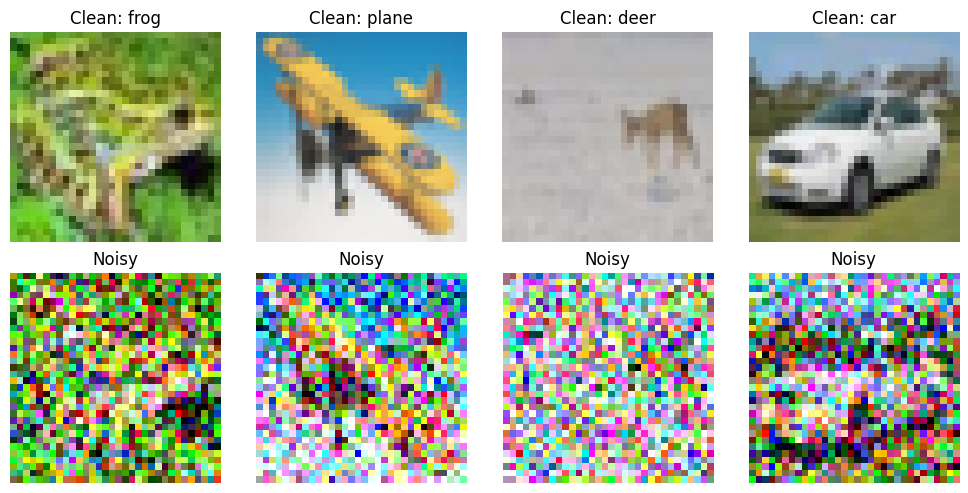

In [3]:
classes = (
    "plane", "car", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
)


def show_image(img: torch.Tensor, title: str = ""):
    img = img.detach().cpu().permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")


sample_images, sample_labels = next(iter(train_loader))
sample_noisy = add_gaussian_noise(sample_images, cfg.noise_factor)

fig = plt.figure(figsize=(10, 5))
for i in range(4):
    plt.subplot(2, 4, i + 1)
    show_image(sample_images[i], f"Clean: {classes[sample_labels[i]]}")

    plt.subplot(2, 4, i + 5)
    show_image(sample_noisy[i], "Noisy")

plt.tight_layout()
plt.show()

## 模型實作

本節為作業核心。請完成三個模型：
1. `Autoencoder`
2. `ResidualAutoencoder`
3. `CustomAutoencoder`

提示：輸入與輸出 tensor shape 需一致，皆為 `(B, 3, 32, 32)`。

### Task A：Autoencoder

Autoencoder 由 **Encoder** 與 **Decoder** 組成：
- Encoder 將輸入影像壓縮成較小的潛在表示（latent representation），保留關鍵結構資訊。
- Decoder 再由潛在表示重建影像，目標是讓輸出盡量接近原圖。

在去噪任務中，模型會學習忽略雜訊、保留內容特徵，重建出較乾淨的影像。

In [4]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        #######################################################################
        # TODO [Task A]
        # 請完成 Autoencoder 架構（encoder + decoder）
        # - encoder 逐步下採樣，抽取潛在表示
        # - decoder 逐步上採樣，重建到原始大小
        # Encoder: 逐步下採樣
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),   # -> (16, H/2, W/2)
            nn.ReLU(),
            
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),  # -> (32, H/4, W/4)
            nn.ReLU(),
            
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # -> (64, H/8, W/8)
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),  # -> (64, H/8, W/8)
            nn.ReLU()
        )
        
        # Decoder: 逐步上採樣
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),  # -> (32, H/4, W/4)
            nn.ReLU(),
            
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),  # -> (32, H/4, W/4)
            nn.ReLU(),
            
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),  # -> (16, H/2, W/2)
            nn.ReLU(),
            
            nn.ConvTranspose2d(16, 3, kernel_size=3, stride=2, padding=1, output_padding=1),   # -> (3, H, W)
            nn.Sigmoid()
        )
        #######################################################################
        

    def forward(self, x):
        #######################################################################
        # TODO [Task A]
        # 回傳重建影像，shape 需與輸入一致
        feat = self.encoder(x) 
        re_x = self.decoder(feat) 
        return re_x
        #######################################################################
        

### Task B：Residual Autoencoder

Residual Autoencoder 在 Autoencoder 的基礎上加入 **Residual Block（skip connection）**。
殘差連接會把輸入直接加回區塊輸出，讓網路更容易學到「需要修正的部分」，通常可提升訓練穩定性與細節重建能力。

In [5]:
class ResidualBlock(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        #######################################################################
        # TODO [Task B]
        # 建立 residual block：conv -> norm -> act -> conv -> norm + skip
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(channels)
        )

        #######################################################################
        

    def forward(self, x):
        #######################################################################
        # TODO [Task B]
        out = self.block(x)
        out = out + x
        return out
        #######################################################################
        


class ResidualAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        #######################################################################
        # TODO [Task B]
        # 使用 residual block 設計 encoder/decoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),     # (B, 16, 16, 16)
            nn.BatchNorm2d(16),
            nn.ReLU(),
            ResidualBlock(16),

            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),    # (B, 32, 8, 8)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            ResidualBlock(32),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),    # (B, 64, 4, 4)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            ResidualBlock(64),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),   # (B, 128, 2, 2)
            nn.BatchNorm2d(128),
            nn.ReLU(),
            ResidualBlock(128)
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),  # (B, 64, 4, 4)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            ResidualBlock(64),

            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),   # (B, 32, 8, 8)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            ResidualBlock(32),

            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),   # (B, 16, 16, 16)
            nn.BatchNorm2d(16),
            nn.ReLU(),
            ResidualBlock(16),

            nn.ConvTranspose2d(16, 3, kernel_size=3, stride=2, padding=1, output_padding=1),    # (B, 3, 32, 32)
            nn.Sigmoid()
        )
        #######################################################################
        

    def forward(self, x):
        #######################################################################
        # TODO [Task B]
        feat = self.encoder(x) 
        re_x = self.decoder(feat) 
        return re_x
        #######################################################################
        

### Task C：自訂模型


In [6]:
class CustomAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        #######################################################################
        # TODO [Task C]
        # 自行設計模型架構
         # Encoder
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.fc_mu = nn.Linear(128, 64)
        self.fc_logvar = nn.Linear(128, 64)
 
        # Decoder
        self.fc2 = nn.Linear(64, 128)
        self.fc3 = nn.Linear(128, 32 * 8 * 8)
        self.conv3 = nn.ConvTranspose2d(32, 16, kernel_size=3, padding=1)
        self.conv4 = nn.ConvTranspose2d(16, 3, kernel_size=3, padding=1)
        #######################################################################
        

    def forward(self, x):
        #######################################################################
        # TODO [Task C]
         # ===== encode =====
        x = nn.functional.relu(self.conv1(x))
        x = nn.functional.max_pool2d(x, 2)
        x = nn.functional.relu(self.conv2(x))
        x = nn.functional.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = nn.functional.relu(self.fc1(x))
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)

        # ===== reparameterize =====
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std

        # ===== decode =====
        z = nn.functional.relu(self.fc2(z))
        z = nn.functional.relu(self.fc3(z))
        z = z.view(z.size(0), 32, 8, 8)
        z = nn.functional.interpolate(z, scale_factor=2)
        z = nn.functional.relu(self.conv3(z))
        z = torch.sigmoid(self.conv4(z))
        z = nn.functional.interpolate(z, scale_factor=2)

        return z
        #######################################################################
        

In [7]:
def sanity_check_model(model: nn.Module, name: str):
    model = model.to(device)
    x = torch.randn(2, 3, 32, 32, device=device)
    y = model(x)
    assert y.shape == x.shape, f"{name} 輸出 shape 錯誤: {y.shape}"
    print(f"{name}: shape check passed -> {tuple(y.shape)}")

## 評估指標：Learned Perceptual Image Patch Similarity（LPIPS）

LPIPS 來自論文 *The Unreasonable Effectiveness of Deep Features as a Perceptual Metric*。
核心想法是：與其直接比較像素差異，不如比較影像在深層網路中的語意特徵差異，較能貼近人類感知。

簡要流程：
1. 將兩張影像送入預訓練網路（常見為 AlexNet / VGG）。
2. 取多層特徵圖並做 channel-wise normalization。
3. 計算對應層特徵差距（加權 L2），再做空間平均並跨層加總得到 LPIPS。

在本作業中，LPIPS 作為主要評估指標，**數值越低表示重建影像在感知上越接近原圖**。

參考：Zhang et al., 2018, [arXiv:1801.03924](https://arxiv.org/abs/1801.03924)


In [8]:
lpips_metric = lpips.LPIPS(net="vgg").to(device).eval()


def compute_lpips(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    # LPIPS 需要輸入範圍在 [-1, 1]
    pred_n = pred * 2.0 - 1.0
    target_n = target * 2.0 - 1.0
    with torch.no_grad():
        score = lpips_metric(pred_n, target_n)
    return score.mean()

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


C:\Users\User\anaconda3\envs\mlterm2\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\User\anaconda3\envs\mlterm2\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: C:\Users\User\anaconda3\envs\mlterm2\lib\site-packages\lpips\weights\v0.1\vgg.pth


## 訓練與驗證流程

In [9]:
def train_one_epoch(
    model: nn.Module,
    loader,
    optimizer: optim.Optimizer,
    noise_factor: float,
) -> Tuple[float, float]:
    model.train()
    loss_meter = 0.0
    lpips_meter = 0.0

    for clean, _ in loader:
        clean = clean.to(device)
        noisy = add_gaussian_noise(clean, noise_factor)

        optimizer.zero_grad(set_to_none=True)
        pred = model(noisy)
        #######################################################################
        # TODO
        # 使用與訓練一致的驗證 loss 設計
        #######################################################################
        loss = nn.functional.mse_loss(pred, clean)

        loss.backward()
        optimizer.step()

        loss_meter += loss.item()
        lpips_meter += float(compute_lpips(pred.detach(), clean.detach()))

    return loss_meter / len(loader), lpips_meter / len(loader)


def evaluate(
    model: nn.Module,
    loader,
    noise_factor: float,
) -> Tuple[float, float]:
    model.eval()
    loss_meter = 0.0
    lpips_meter = 0.0

    with torch.no_grad():
        for clean, _ in loader:
            clean = clean.to(device)
            noisy = add_gaussian_noise(clean, noise_factor)
            pred = model(noisy)
            #######################################################################
            # TODO
            #######################################################################
            loss = nn.functional.mse_loss(pred, clean)
            loss_meter += loss.item()

            lpips_meter += float(compute_lpips(pred, clean))

    return loss_meter / len(loader), lpips_meter / len(loader)


def train_model(
    model: nn.Module,
    train_loader,
    test_loader,
    config: ExperimentConfig,
    model_name: str,
) -> Dict[str, list]:
    optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)
    history = {
        "train_mse": [],
        "train_lpips": [],
        "test_mse": [],
        "test_lpips": [],
    }

    for epoch in range(config.epochs):
        t0 = time.time()
        tr_mse, tr_lpips = train_one_epoch(model, train_loader, optimizer, config.noise_factor)
        te_mse, te_lpips = evaluate(model, test_loader, config.noise_factor)

        history["train_mse"].append(tr_mse)
        history["train_lpips"].append(tr_lpips)
        history["test_mse"].append(te_mse)
        history["test_lpips"].append(te_lpips)

        print(
            f"[{model_name}] Epoch {epoch+1:02d}/{config.epochs} | "
            f"Train MSE: {tr_mse:.4f}, Train LPIPS: {tr_lpips:.4f} | "
            f"Test MSE: {te_mse:.4f}, Test LPIPS: {te_lpips:.4f} | "
            f"{time.time() - t0:.1f}s"
        )

    return history

## 執行實驗

In [10]:
models = {
    "autoencoder": Autoencoder().to(device),
    "residual_autoencoder": ResidualAutoencoder().to(device),
    "custom_autoencoder": CustomAutoencoder().to(device),
}
#######################################################################
# TODO: 可自行調整訓練參數
#######################################################################
cfg.epochs = 20
cfg.learning_rate = 1e-3
cfg.noise_factor = 0.35
#######################################################################

histories = {}
for name, model in models.items():
    sanity_check_model(model, name)
    histories[name] = train_model(model, train_loader, test_loader, cfg, name)

autoencoder: shape check passed -> (2, 3, 32, 32)
[autoencoder] Epoch 01/20 | Train MSE: 0.0292, Train LPIPS: 0.6721 | Test MSE: 0.0210, Test LPIPS: 0.6469 | 36.1s
[autoencoder] Epoch 02/20 | Train MSE: 0.0184, Train LPIPS: 0.6233 | Test MSE: 0.0166, Test LPIPS: 0.6003 | 25.5s
[autoencoder] Epoch 03/20 | Train MSE: 0.0148, Train LPIPS: 0.5750 | Test MSE: 0.0136, Test LPIPS: 0.5602 | 21.7s
[autoencoder] Epoch 04/20 | Train MSE: 0.0133, Train LPIPS: 0.5477 | Test MSE: 0.0133, Test LPIPS: 0.5371 | 21.6s
[autoencoder] Epoch 05/20 | Train MSE: 0.0126, Train LPIPS: 0.5314 | Test MSE: 0.0126, Test LPIPS: 0.5255 | 22.4s
[autoencoder] Epoch 06/20 | Train MSE: 0.0121, Train LPIPS: 0.5212 | Test MSE: 0.0117, Test LPIPS: 0.5150 | 23.6s
[autoencoder] Epoch 07/20 | Train MSE: 0.0116, Train LPIPS: 0.5108 | Test MSE: 0.0113, Test LPIPS: 0.5060 | 23.2s
[autoencoder] Epoch 08/20 | Train MSE: 0.0112, Train LPIPS: 0.5020 | Test MSE: 0.0114, Test LPIPS: 0.4985 | 22.5s
[autoencoder] Epoch 09/20 | Train MSE:


=== Final Test LPIPS (lower is better) ===
1. residual_autoencoder   LPIPS = 0.3686
2. autoencoder            LPIPS = 0.4262
3. custom_autoencoder     LPIPS = 0.5375


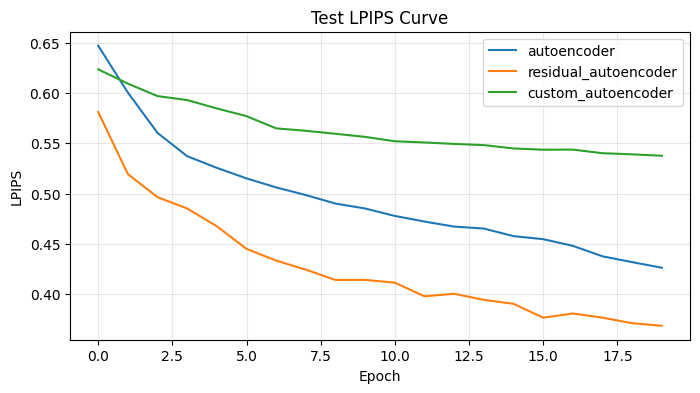

In [11]:
def summarize_lpips(histories: Dict[str, Dict[str, list]]):
    print("\n=== Final Test LPIPS (lower is better) ===")
    summary = []
    for name, h in histories.items():
        final_lpips = h["test_lpips"][-1]
        summary.append((name, final_lpips))
    summary = sorted(summary, key=lambda x: x[1])
    for rank, (name, score) in enumerate(summary, 1):
        print(f"{rank}. {name:<22s} LPIPS = {score:.4f}")


summarize_lpips(histories)

plt.figure(figsize=(8, 4))
for name, h in histories.items():
    plt.plot(h["test_lpips"], label=name)
plt.xlabel("Epoch")
plt.ylabel("LPIPS")
plt.title("Test LPIPS Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 視覺化重建結果

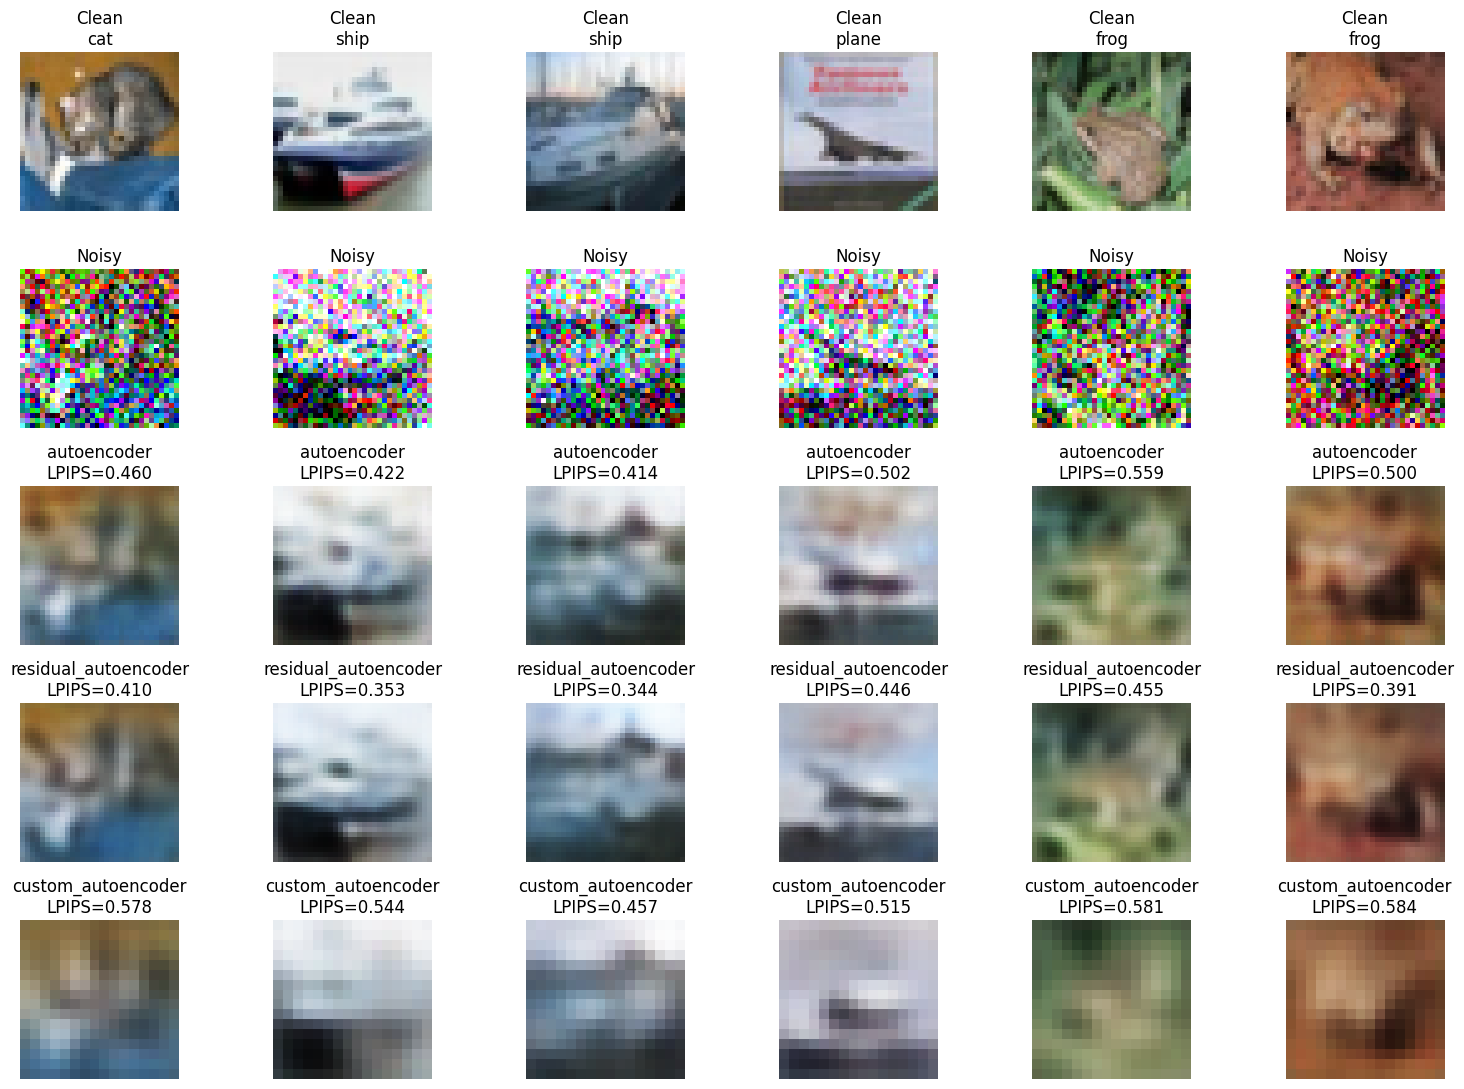

In [12]:
def visualize_denoising(models: Dict[str, nn.Module], loader, noise_factor: float, max_images: int = 6):
    clean, labels = next(iter(loader))
    clean = clean[:max_images].to(device)
    noisy = add_gaussian_noise(clean, noise_factor)

    preds = {}
    for name, model in models.items():
        model.eval()
        with torch.no_grad():
            preds[name] = model(noisy)

    n_rows = 2 + len(models)
    plt.figure(figsize=(2.6 * max_images, 2.2 * n_rows))

    for i in range(max_images):
        plt.subplot(n_rows, max_images, i + 1)
        show_image(clean[i], f"Clean\n{classes[labels[i]]}")

        plt.subplot(n_rows, max_images, i + 1 + max_images)
        show_image(noisy[i], "Noisy")

    row_offset = 2
    for row, (name, pred_batch) in enumerate(preds.items()):
        for i in range(max_images):
            lp = compute_lpips(pred_batch[i:i+1], clean[i:i+1]).item()
            idx = (row_offset + row) * max_images + i + 1
            plt.subplot(n_rows, max_images, idx)
            show_image(pred_batch[i], f"{name}\nLPIPS={lp:.3f}")

    plt.tight_layout()
    plt.show()


visualize_denoising(models, test_loader, cfg.noise_factor, max_images=6)